# Exploratory Data Analysis

The final machine learning dataset was explored to understand the distribution of molecular descriptors and biological activity values prior to model development.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

model_df = pd.read_csv(
    "../data_clean/leishmania_ml_dataset.csv"
)
model_df.head()


,Molecule ChEMBL ID,SMILES,pIC50,Molecular_Weight,AlogP,TPSA,HBA,HBD,RO5_Violations,Rotatable_Bonds,QED,Aromatic_Rings,Heavy_Atoms,NP_Likeness
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,3.940555,388.90,3.15,53.01,4.0,1.0,0.0,8.0,0.70,2.0,27.0,-1.21
1,CHEMBL100210,CCCC[C@H]1C(=O)O[C@@H]2O[C@@]3(CC)CC[C@H]4[C@H...,4.443697,338.44,3.96,53.99,5.0,0.0,0.0,4.0,0.57,0.0,24.0,2.52
2,CHEMBL100740,C[C@@H]1CC[C@H]2[C@@H](C)C(=O)O[C@@H]3OC(C)(C)...,3.800519,284.35,2.64,53.99,5.0,0.0,0.0,0.0,0.51,0.0,20.0,2.66
3,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,5.242633,344.85,5.38,17.82,2.0,0.0,1.0,4.0,0.45,4.0,25.0,-0.58
4,CHEMBL106,OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F,3.898138,306.28,0.74,81.65,7.0,1.0,0.0,5.0,0.75,3.0,22.0,-0.86


## Dataset Overview

The dimensions and structure of the final modeling dataset were examined to verify the number of compounds and descriptor variables available for machine learning.

In [5]:
print(model_df.shape)
model_df.info()

(5457, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5457 entries, 0 to 5456
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Molecule ChEMBL ID  5457 non-null   str    
 1   SMILES              5457 non-null   str    
 2   pIC50               5457 non-null   float64
 3   Molecular_Weight    5457 non-null   float64
 4   AlogP               5457 non-null   float64
 5   TPSA                5457 non-null   float64
 6   HBA                 5457 non-null   float64
 7   HBD                 5457 non-null   float64
 8   RO5_Violations      5457 non-null   float64
 9   Rotatable_Bonds     5457 non-null   float64
 10  QED                 5457 non-null   float64
 11  Aromatic_Rings      5457 non-null   float64
 12  Heavy_Atoms         5457 non-null   float64
 13  NP_Likeness         5457 non-null   float64
dtypes: float64(12), str(2)
memory usage: 597.0 KB


## Summary Statistics

Descriptive statistics were generated to summarize the central tendency, variability, and range of the molecular descriptors and pIC50 values.

In [6]:
model_df.describe()

,pIC50,Molecular_Weight,AlogP,TPSA,HBA,HBD,RO5_Violations,Rotatable_Bonds,QED,Aromatic_Rings,Heavy_Atoms,NP_Likeness
count,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.000000,5457.00000
mean,4.903216,391.876885,3.769938,76.529318,5.213304,1.324537,0.359721,5.815833,0.529031,2.444567,27.063955,-0.58521
std,0.836646,112.188324,1.826055,37.174120,2.263835,1.382643,0.669133,3.840237,0.219353,1.235879,7.616744,1.22583
min,2.691895,90.130000,-8.860000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000,0.000000,6.000000,-3.28000
25%,4.300000,318.360000,2.680000,50.420000,4.000000,0.000000,0.000000,3.000000,0.370000,2.000000,22.000000,-1.46000
50%,4.795880,374.400000,3.650000,70.980000,5.000000,1.000000,0.000000,5.000000,0.540000,2.000000,26.000000,-0.86000
75%,5.350000,448.540000,4.750000,96.690000,7.000000,2.000000,1.000000,7.000000,0.710000,3.000000,31.000000,0.10000
max,9.372364,1310.530000,12.860000,347.320000,19.000000,13.000000,4.000000,34.000000,0.950000,11.000000,76.000000,4.00000


## Distribution of Biological Activity

The distribution of pIC50 values was examined to assess the range of anti-leishmanial activity represented in the dataset.

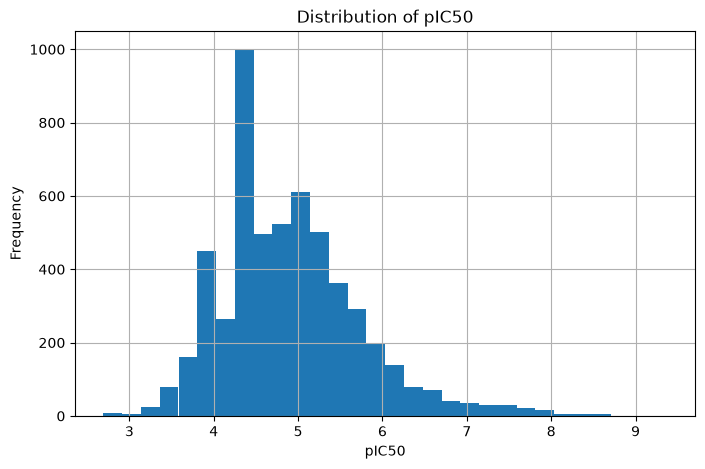

In [7]:
plt.figure(figsize=(8,5))

model_df["pIC50"].hist(bins=30)

plt.xlabel("pIC50")
plt.ylabel("Frequency")
plt.title("Distribution of pIC50")

plt.show()

## Distribution of pIC50 Values

A histogram of pIC50 values was generated to visualize the distribution of anti-leishmanial activity within the dataset. The distribution was examined to assess the range of biological activities and identify any potential skewness or extreme values that could influence model performance.

In [8]:
corr_matrix = model_df.select_dtypes(
    include="number"
).corr()

corr_matrix

,pIC50,Molecular_Weight,AlogP,TPSA,HBA,HBD,RO5_Violations,Rotatable_Bonds,QED,Aromatic_Rings,Heavy_Atoms,NP_Likeness
pIC50,1.000000,0.151014,0.226985,0.003982,0.031222,-0.028042,0.117513,0.054527,-0.154020,0.157051,0.157892,0.004822
Molecular_Weight,0.151014,1.000000,0.450611,0.427952,0.483151,0.261286,0.658636,0.562884,-0.580756,0.256584,0.915166,0.102448
AlogP,0.226985,0.450611,1.000000,-0.302305,-0.240003,-0.163289,0.561156,0.356404,-0.411170,0.323318,0.514071,0.144700
TPSA,0.003982,0.427952,-0.302305,1.000000,0.785107,0.599231,0.254672,0.301222,-0.443896,0.059148,0.472117,0.016772
HBA,0.031222,0.483151,-0.240003,0.785107,1.000000,0.259944,0.265498,0.281881,-0.336825,0.118869,0.516534,-0.038010
HBD,-0.028042,0.261286,-0.163289,0.599231,0.259944,1.000000,0.253169,0.198006,-0.269314,0.075691,0.290205,0.142548
RO5_Violations,0.117513,0.658636,0.561156,0.254672,0.265498,0.253169,1.000000,0.477644,-0.628908,0.183362,0.718465,0.238701
Rotatable_Bonds,0.054527,0.562884,0.356404,0.301222,0.281881,0.198006,0.477644,1.000000,-0.611999,-0.076472,0.603930,0.082782
QED,-0.154020,-0.580756,-0.411170,-0.443896,-0.336825,-0.269314,-0.628908,-0.611999,1.000000,-0.170976,-0.631433,-0.221123
Aromatic_Rings,0.157051,0.256584,0.323318,0.059148,0.118869,0.075691,0.183362,-0.076472,-0.170976,1.000000,0.294880,-0.444607


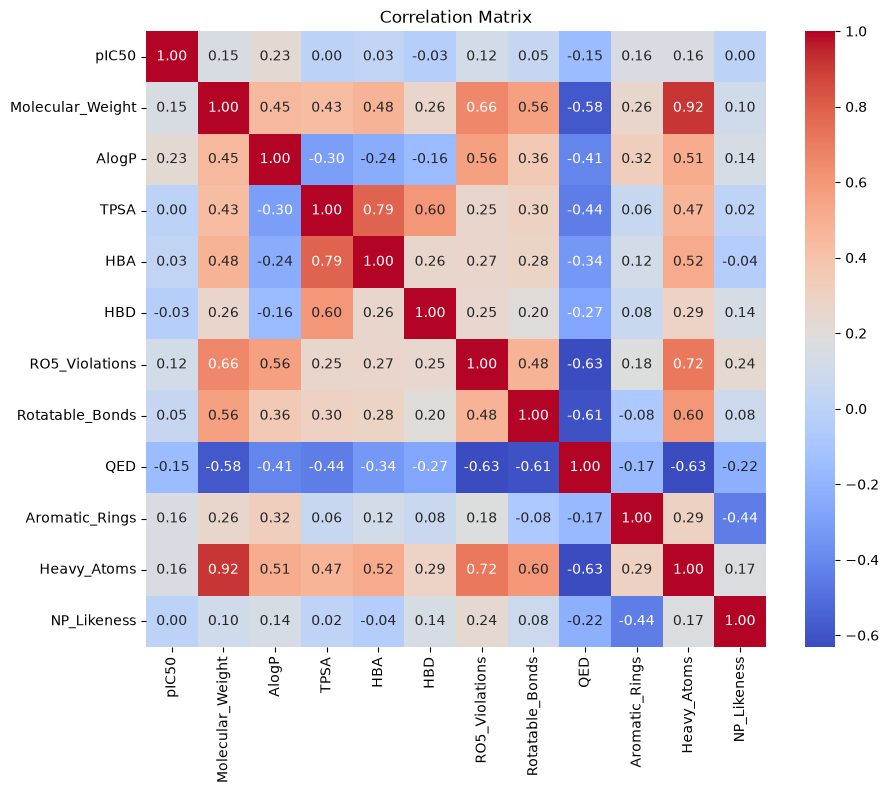

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

A correlation matrix was generated to evaluate relationships among molecular descriptors and biological activity values. This analysis helps identify strongly correlated features and provides insight into potential factors influencing anti-leishmanial activity.

In [10]:
corr_matrix["pIC50"].sort_values(
    ascending=False
)

pIC50               1.000000
AlogP               0.226985
Heavy_Atoms         0.157892
Aromatic_Rings      0.157051
Molecular_Weight    0.151014
RO5_Violations      0.117513
Rotatable_Bonds     0.054527
HBA                 0.031222
NP_Likeness         0.004822
TPSA                0.003982
HBD                -0.028042
QED                -0.154020
Name: pIC50, dtype: float64

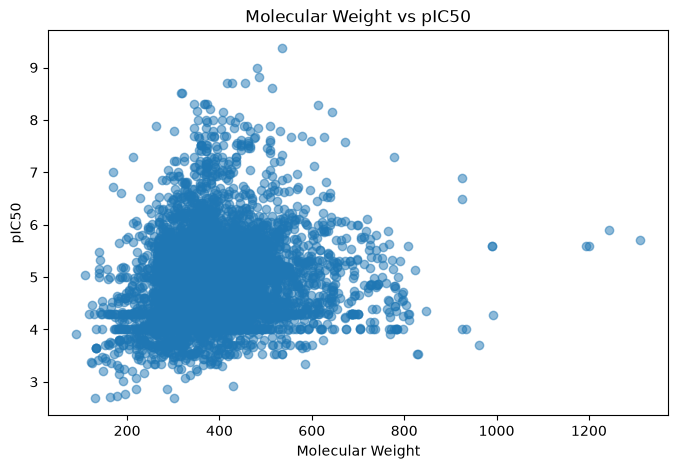

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    model_df["Molecular_Weight"],
    model_df["pIC50"],
    alpha=0.5
)

plt.xlabel("Molecular Weight")
plt.ylabel("pIC50")
plt.title("Molecular Weight vs pIC50")

plt.show()

## Relationship Between Molecular Weight and Biological Activity

A scatter plot was generated to examine the relationship between molecular weight and anti-leishmanial activity (pIC50). This visualization was used to identify potential trends, clusters, and outliers that may not be apparent from correlation analysis alone.

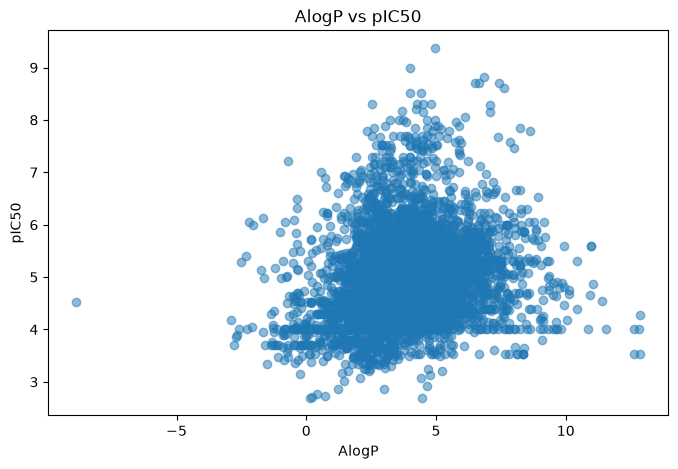

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    model_df["AlogP"],
    model_df["pIC50"],
    alpha=0.5
)

plt.xlabel("AlogP")
plt.ylabel("pIC50")
plt.title("AlogP vs pIC50")

plt.show()

## Relationship Between Lipophilicity and Biological Activity

A scatter plot was generated to investigate the relationship between lipophilicity (AlogP) and anti-leishmanial activity (pIC50). Lipophilicity is an important physicochemical property that can influence membrane permeability, absorption, and intracellular target access.

In [13]:
model_df.sort_values(
    "pIC50",
    ascending=False
)[
    [
        "Molecule ChEMBL ID",
        "pIC50",
        "Molecular_Weight",
        "AlogP"
    ]
].head(20)

,Molecule ChEMBL ID,pIC50,Molecular_Weight,AlogP
881,CHEMBL218650,9.372364,534.49,4.97
4216,CHEMBL4763675,9.000000,480.52,3.99
913,CHEMBL231385,8.823909,486.69,6.84
4780,CHEMBL520624,8.698970,456.07,7.44
4424,CHEMBL482925,8.698970,428.02,6.66
4435,CHEMBL484303,8.698970,416.01,6.51
914,CHEMBL231386,8.602060,514.74,7.62
3009,CHEMBL3623308,8.522879,318.79,4.01
5344,CHEMBL6091925,8.522879,317.52,4.44
5358,CHEMBL6133880,8.301030,365.52,4.48


## Identification of Highly Active Compounds

The compounds were ranked according to their pIC50 values to identify the most potent anti-leishmanial molecules in the dataset. The physicochemical properties of these highly active compounds were examined to identify common characteristics associated with increased biological activity.

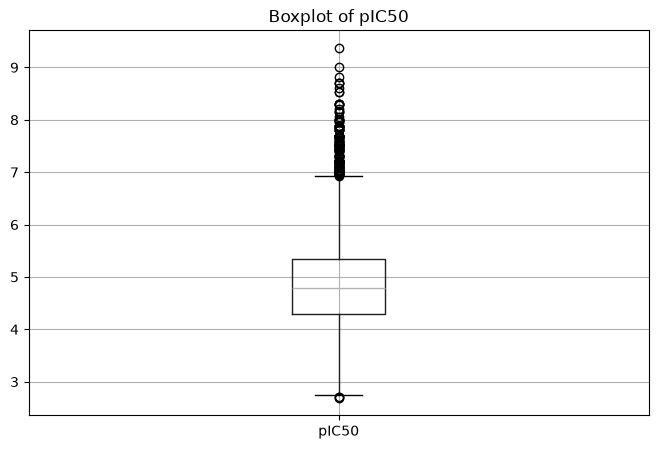

In [14]:
plt.figure(figsize=(8,5))

model_df.boxplot(
    column="pIC50"
)

plt.title("Boxplot of pIC50")

plt.show()

## Boxplot of pIC50 Values

A boxplot was generated to visualize the distribution of pIC50 values and identify potential outliers. The majority of compounds were concentrated within a relatively narrow activity range, while a smaller number of highly potent compounds appeared as upper-tail outliers. These outliers were retained because they likely represent genuinely active compounds rather than data quality issues.